In [2]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from RENDES_fizinfo import *

In [3]:
# Gy / 9. feladat [20 p]
# 
# Az órai anyagban tanult „pattogós labda modell” segítségével modellezze egy kosárlabda mozgását 
# az alábbi paraméterekkel:
# 
# A labdát vegyük 76 cm kerületűnek, 
# 590 g tömegűnek; 
# a pattogáskor vett D érték legyen 4000 N/m, 
# a pattanáskori fékeződési erő pedig 3 N.
# 
# A labdát 1,9 m magasról, a vízszintessel 40 fokos szöget bezáróan, 10 m/s sebességgel indítjuk.
# 
# a) Rajzolja fel a labda pályáját az első 20 másodpercben, feltéve, hogy nem ütközik semminek! [2 p]
# 
# b) Mikor, az eldobás helyétől milyen távol, és milyen sebességgel éri el a talajt először a labda? [4 p]
# 
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt 2,6 m magasra tudja nyújtani a kezét, 
# akkor átrepül-e felette a labda? [4 p]
# 
# d) Készítsen táblázatot, 
# amely a pálya lokálisan legmagasabb pontjaira adja meg sorra az időpontot, 
# az x és y koordinátát, valamint a sebesség nagyságát! 
# Azaz az egymás utáni ívek felső pontjait kell megtalálni. [5 p]

In [4]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):
    """
    Visszaadja egy labda erő- és tömegfüggvényét gravitáció,
    közegellenállás és rugalmas talajtól való visszapattanás figyelembevételével.

    Paraméterek:
        m    : labda tömege [kg]
        C    : közegellenállási együttható (C_D)
        A    : labda homlokfelülete [m²]
        rho  : közeg sűrűsége [kg/m³]
        D    : rugalmas talajmodell merevségi együtthatója [N/m]
              (talaj-reakcióerő: F_talaj = D * behatolás, ha y <= 0)
        F_f  : súrlódási erő nagysága a talajon [N]
              (vízszintes irányban lassít, ha a labda érinti a talajt)
        g    : gravitációs gyorsulás [m/s²]
    """

    def tomeg_fuggveny(t):
        # A labda tömege állandó (nincs tömegváltozás)
        return m

    def ero_fuggveny(t, helyzet, sebesseg, tomeg):
        """
        Az összes erő eredője [N], 2D vektorként (x, y).

        Hatások:
          - gravitáció         : lefelé (y irány)
          - közegellenállás    : sebességgel ellentétes, v²-tel arányos
          - talaj reakcióerő   : felfelé, ha y <= 0 (rugalmas behatolás)
          - talaj súrlódás     : vízszintes irányban, ha y <= 0
        """

        eredo_ero = np.array([0.0, 0.0], dtype=np.float64)

        # --- Gravitációs erő ---
        eredo_ero[1] -= tomeg * g                          # F_g = -m·g (y irányban lefelé)

        # --- Közegellenállási erő ---
        sebesseg_nagysag = np.sqrt((sebesseg ** 2).sum())  # |v| [m/s]
        if sebesseg_nagysag > 1e-10:
            eredo_ero -= 0.5 * C * A * rho \
                         * sebesseg * sebesseg_nagysag     # F_drag = ½·C·A·ρ·v·|v|, iránya: -v̂

        # --- Talaj reakcióerő (rugalmas ütközésmodell) ---
        y = helyzet[1]
        vy = sebesseg[1]
        if y <= 0.0:                        # labda elérte / átment a talajon
            behatolas = -y                  # behatolás mélysége [m] (pozitív)
            eredo_ero[1] += D * behatolas   # F_talaj = D · δ (felfelé)

            # Talaj súrlódás: csak ha a labda érinti a talajt és mozog vízszintesen
            vx = sebesseg[0]
            if abs(vx) > 1e-10:
                eredo_ero[0] -= F_f * np.sign(vx)    # F_súrl = -F_f · sign(vx)

        return eredo_ero

    return ero_fuggveny, tomeg_fuggveny

# --- Labda fizikai paraméterei ---
m_basketball = 0.59          # labda tömege [kg]
perim_ball   = 0.76          # labda kerülete [m]

r   = perim_ball / (2 * np.pi)   # labda sugara [m]
A   = np.pi * r**2               # homlokfelület (keresztmetszet) [m²]
C   = 0.47                       # közegellenállási együttható (gömb)
rho = 1.3                        # levegő sűrűsége [kg/m³]
g   = 9.81                       # gravitációs gyorsulás [m/s²]

# --- Talajmodell paraméterei ---
D   = 4000.0   # rugalmas talaj merevségi együtthatója [N/m]
F_f = 3.0      # talaj súrlódási erő [N]

# --- Erő- és tömegfüggvény példányosítása ---
ero_fuggveny, tomeg_fuggveny = create_grav_közeg_talaj_F_m(m_basketball, C, A, rho, D, F_f, g)

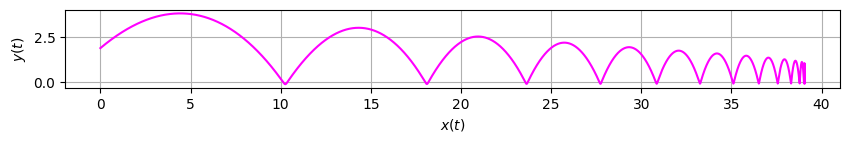

In [5]:
# ============================================================
# a) Pályagörbe – 1,9 m magasról, 40°, 10 m/s, 20 másodperc
#    (nem ütközik semminek → talajmodell nem aktiválódik,
#     csak gravitáció + közegellenállás hat)
# ============================================================

# --- Kezdőfeltételek ---
kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 1.9  # kezdeti y pozíció [m] (1.8 m magasról indítjuk)

indulo_sebesseg     = 10.0   # kezdeti sebesség nagysága [m/s]
indulo_szog_fok     = 40.0   # indulási szög (vízszintestől) [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

ball_din = num_dinam(2)                     # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 20.0, 0.001)    # t ∈ [0, 20] s, dt = 0,001 s


ball_din.set_F_fun(ero_fuggveny)           # erőfüggvény (gravitáció + drag + tolóerő)
ball_din.set_mass_fun(tomeg_fuggveny)      # tömegfüggvény (hajtóanyag-fogyás)
ball_din.set_r0_v0([kezdo_x, kezdo_y],     # kezdeti helyzet:  [0 m, 1.8 m]
                     [kezdo_vx, kezdo_vy]) # kezdeti sebesség: 55°, 10 m/s
# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)
ball_din.calc_r_to_v()

# --- Pályagörbe megjelenítése ---
ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán

In [6]:
# b) Mikor, az eldobás helyétől milyen távol, és milyen sebességgel éri el a talajt először a labda? [4 p]

elso_foldeteres = arg_eq(ball_din.r_y,0.00)[0]

print(f'A labda elosszor {ball_din.t[elso_foldeteres]:.2f} s nél ér foldet')
print(f'A labda sebessegel {ball_din.v_abs[elso_foldeteres]:.2f} m/s-el ér foldet')

A labda elosszor 1.52 s nél ér foldet
A labda sebessegel 9.96 m/s-el ér foldet


In [7]:
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt 2,6 m magasra tudja nyújtani a kezét, 
# akkor átrepül-e felette a labda? [4 p]

valaki_x = 3
valaki_y = 2

print(f'A labda atrepul: {ball_din.flies_over_obstacle(valaki_x,valaki_y)[0]}')


A labda atrepul: True


In [8]:
# d) Készítsen táblázatot, 
# amely a pálya lokálisan legmagasabb pontjaira adja meg sorra az időpontot, 
# az x és y koordinátát, valamint a sebesség nagyságát! 
# Azaz az egymás utáni ívek felső pontjait kell megtalálni. [5 p]


# Megkeressük azokat az indexeket, ahol a v_y sebességkomponens áthalad a 0 értéken.
# amikor v_y = 0 ott vált előjelet tehát vagy fent vagy lent van
ind_holtpont = arg_eq(ball_din.v_y, 0.0)

# Számláló a kiíráshoz.
v = 0

# A v_y = 0 helyek között lehetnek felső és alsó holtpontok is.
# Felső holtpontnál a gyorsulás y komponense negatív,
# mert a labdára lefelé hat az eredő gyorsulás.
# Így kiszűrjük azokat a pontokat, amelyek tényleg a pályaívek tetején vannak.
ind_felsoholtpont = ind_holtpont[ball_din.a[ind_holtpont, 1] < 0]

# Az első 10 felső holtpont adatainak kiírása.
for i in ind_felsoholtpont[:10]:
    # Kiírjuk:
    #   - a holtpont sorszámát,
    #   - a sebesség nagyságát,
    #   - az x koordinátát,
    #   - az y koordinátát.
    print(f'{v+1}. holtpont\tv: '+
          f'{ball_din.v_abs[i]:.2f} m/s\t'
          f'x: {ball_din.r_x[i]:.2f} m\t'
          f'y: {ball_din.r_y[i]:.2f} m')
    
    # Sorszám növelése a következő holtpont kiírásához.
    v = v+1



1. holtpont	v: 6.81 m/s	x: 4.42 m	y: 3.83 m
2. holtpont	v: 4.87 m/s	x: 14.32 m	y: 3.03 m
3. holtpont	v: 3.74 m/s	x: 20.95 m	y: 2.54 m
4. holtpont	v: 2.97 m/s	x: 25.73 m	y: 2.20 m
5. holtpont	v: 2.40 m/s	x: 29.32 m	y: 1.95 m
6. holtpont	v: 1.94 m/s	x: 32.07 m	y: 1.76 m
7. holtpont	v: 1.57 m/s	x: 34.20 m	y: 1.60 m
8. holtpont	v: 1.24 m/s	x: 35.82 m	y: 1.48 m
9. holtpont	v: 0.96 m/s	x: 37.05 m	y: 1.37 m
10. holtpont	v: 0.70 m/s	x: 37.94 m	y: 1.28 m
